Вариант задания определяется согласно предложенному скрипту:

In [1]:
surname = "Новиков"  # Ваша фамилия

alph = 'абвгдеёжзийклмнопрстуфхцчшщъыьэюя'
w = [4, 42, 21, 21, 55,  1, 44, 26, 18, 3, 38, 26, 18, 12,  3, 49, 45,
        7, 42, 9,  4,  3, 36, 33, 31, 29,  5, 4,  4, 19, 21, 27, 33]
d = dict(zip(alph, w))
variant =  sum([d[el] for el in surname.lower()]) % 40 + 1

print("Задание № 2. Вариант: ", variant % 2 + 1)
print("Задание № 3. Вариант: ", variant % 3 + 1 )

Задание № 2. Вариант:  2
Задание № 3. Вариант:  2


# Задача 1. Реализация собственных классов и функций

## 1 пункт
Реализовать класс, предназначенный для оценки параметров линейной регрессии с регуляризацией совместимый с `sklearn`. 

Передаваемые параметры: 
1. коэффициент регуляризации (*alpha*). 

Использовать **метод наименьших квадратов с регуляризацией**.

Подключаем необходимые библиотеки:

In [74]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

from sklearn.base import BaseEstimator, RegressorMixin, TransformerMixin
from sklearn.utils.validation import check_X_y, check_array, check_is_fitted

Определим класс, реализующий ридж-регрессию (*формула известна*).

Класс будет оценивать параметры линейной регрессии с заданной регуляризацией.

Родительским для нашего класса будут: 
* `BaseEstimator` - базовый для всех моделей в sklearn
* `RegressorMixin` - это добавка, которая говорит: "модель — это регрессор"

In [90]:
class CustomLinearRegression(BaseEstimator, RegressorMixin):
    
    def __init__(self, alpha=1.0, method='ridge'):
        self.alpha = alpha
        self.method = method
    
    def fit(self, X, y):
        X_b = np.hstack([np.ones((X.shape[0], 1)), X])
        n_features = X_b.shape[1]
        I = np.eye(n_features)
        I[0, 0] = 0
        self.coef_ = np.linalg.inv(X_b.T @ X_b + self.alpha * I) @ X_b.T @ y
        return self

    def predict(self, X):
        X_b = np.hstack([np.ones((X.shape[0], 1)), X])
        return X_b @ self.coef_

In [91]:
# import pandas as pd

# class CustomLinearRegression(BaseEstimator, RegressorMixin):
    
#     def __init__(self, alpha=1.0, method='ridge'):
#         self.alpha = alpha
#         self.method = method
    
#     def fit(self, X, y):
#         # Сохраняем, были ли имена признаков
#         self.feature_names_in_ = X.columns if isinstance(X, pd.DataFrame) else [f"x{i}" for i in range(X.shape[1])]

#         X_np = X.to_numpy() if isinstance(X, pd.DataFrame) else X
#         y_np = y.to_numpy() if isinstance(y, pd.Series) else y

#         X_b = np.hstack([np.ones((X_np.shape[0], 1)), X_np])
#         n_features = X_b.shape[1]

#         I = np.eye(n_features)
#         I[0, 0] = 0  # не регуляризуем сдвиг (bias)

#         self.coef_ = np.linalg.inv(X_b.T @ X_b + self.alpha * I) @ X_b.T @ y_np

#         # Сохраняем отдельно коэффициенты
#         self.intercept_ = self.coef_[0]
#         self.coef_ = self.coef_[1:]

#         # Оборачиваем в pandas.Series для удобства
#         self.coef_ = pd.Series(self.coef_, index=self.feature_names_in_)
        
#         return self

#     def predict(self, X):
#         X_np = X.to_numpy() if isinstance(X, pd.DataFrame) else X
#         return X_np @ self.coef_.values + self.intercept_


Теперь проверим написаный класс на практике. 
Для этого подготовим данные, с которыми будем работать

In [92]:
def generate_data(n=100, start_x=4, length_x=8, mu=0, sigma=0.5):
    """Генерация данных."""
    from scipy import stats
    f = lambda x: 2 + 0.3*x
    x = stats.uniform.rvs(size=n, loc=start_x, scale=length_x, random_state=1)
    e = stats.norm.rvs(size=n, loc=mu, scale=sigma, random_state=1)
    return x.reshape(-1,1), f(x) + e

In [93]:
# def plot_regression(X, y, model=None):
#     """
#     Функция для отображения наблюдений и линии регрессии.

#     Parameters:
#     X : numpy array, shape (n_samples, n_features)
#         Входные данные (матрица признаков).
#     y : numpy array, shape (n_samples,)
#         Целевые значения (метки).
#     model : объект модели, который имеет метод predict
#         Модель, предсказывающая значения для регрессионной линии.
#     """
#     plt.figure(2, figsize=[4, 4])
    
#     xx = np.linspace(X[:, 0].min(), X[:, 0].max(), 2).reshape(-1, 1)

#     plt.subplot(1, 1, 1)
#     plt.scatter(X[:, 0], y, color="green", label="Sample", zorder=2)
#     if model:
#         plt.plot(xx, model.predict(xx), "-", color="grey", label="Regression")
#     plt.xlabel("$x$")
#     plt.ylabel("$f(x)$")
#     plt.legend()
#     plt.grid(True)
#     plt.show()
    
def plot_regression(X, y, model=None):
    """
    Функция для отображения наблюдений и линии регрессии.

    Parameters:
    X : pandas.DataFrame, shape (n_samples, 1)
        Входные данные (один признак).
    y : pandas.Series, shape (n_samples,)
        Целевые значения (метки).
    model : объект модели, который имеет метод predict
        Модель, предсказывающая значения для регрессионной линии.
    """
    plt.figure(figsize=[4, 4])

    # Получаем имя столбца и извлекаем значения
    col_name = X.columns[0]
    x_vals = X[col_name]
    
    # Для построения линии регрессии генерируем 2 значения на отрезке
    xx = np.linspace(x_vals.min(), x_vals.max(), 2).reshape(-1, 1)

    plt.scatter(x_vals, y, color="green", label="Sample", zorder=2)
    if model:
        plt.plot(xx, model.predict(xx), "-", color="grey", label="Regression")
    plt.xlabel(col_name)
    plt.ylabel("$f(x)$")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()
    
def plot_all_params_regression(X, y, model=None):
    for column in X.columns:
        print(f"\n--- Plotting for feature: {column} ---")
        plot_regression(X[[column]], y, model) 
        

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

def plot_all_features_with_model(X: pd.DataFrame, y: pd.Series, model=None, log_scale=False):
    """
    Отображает все признаки X и целевую переменную y на одном графике.
    Каждому признаку соответствует свой цвет. Если передана модель — 
    отображает также линию предсказаний.

    Parameters:
    X : pandas.DataFrame, shape (n_samples, n_features)
        Матрица признаков.
    y : pandas.Series, shape (n_samples,)
        Целевые значения.
    model : объект с методом predict или None
        Обученная модель для построения линии регрессии.
    log_scale : bool, optional (default=False)
        Если True — устанавливает логарифмическую шкалу по обеим осям.
        Если False — линейная шкала.
    """
    plt.figure(figsize=(10, 8))  # увеличенный размер

    colors = plt.cm.tab20.colors  # палитра из 20 цветов

    for i, column in enumerate(X.columns):
        color = colors[i % len(colors)]
        plt.scatter(X[column], y, label=f"{column}", alpha=0.6, color=color)

    if model is not None:
        y_pred = model.predict(X)
        plt.plot(sorted(y_pred), sorted(y), '-', color='black', label="Model prediction")

    if log_scale:
        plt.xscale('log')
        plt.yscale('log')
    else:
        plt.xscale('linear')
        plt.yscale('linear')

    plt.xlabel("Feature value" + (" (log scale)" if log_scale else ""))
    plt.ylabel("Target $f(x)$" + (" (log scale)" if log_scale else ""))
    plt.legend()
    plt.grid(True, which="both" if log_scale else 'major', ls="--", linewidth=0.5)
    plt.tight_layout()
    plt.show()

In [94]:
# X, y = generate_data()
import pandas as pd

In [95]:
# Загрузка файла
df = pd.read_csv("./regularization.csv")  # замени на реальное имя файла

# Разделение на X и y
X = df.drop(columns="Y")  # все столбцы кроме Y
y = df["Y"]                # только столбец Y

In [96]:
X.columns

Index(['X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X7', 'X8', 'X9', 'X10', 'X11',
       'X12', 'X13', 'X14', 'X15', 'X16'],
      dtype='object')

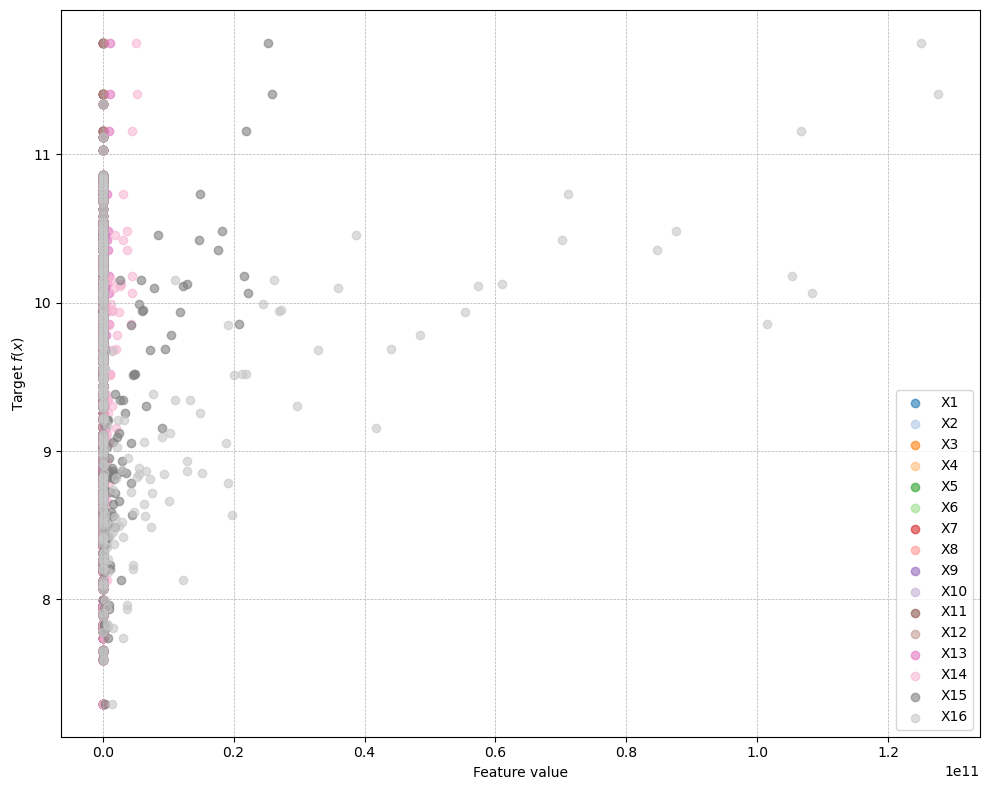

In [97]:
# Отображение наблюдений
# for column in X.columns:
#     print(f"\n--- Plotting for feature: {column} ---")
#     plot_regression(X[[column]], y)


# plot_all_params_regression(X, y)

plot_all_features_with_model(X, y)

Никакой упорядоченности тут не видно, но возможно это связано с масштабом, попробуем вывести график с логарифмическими шкалами

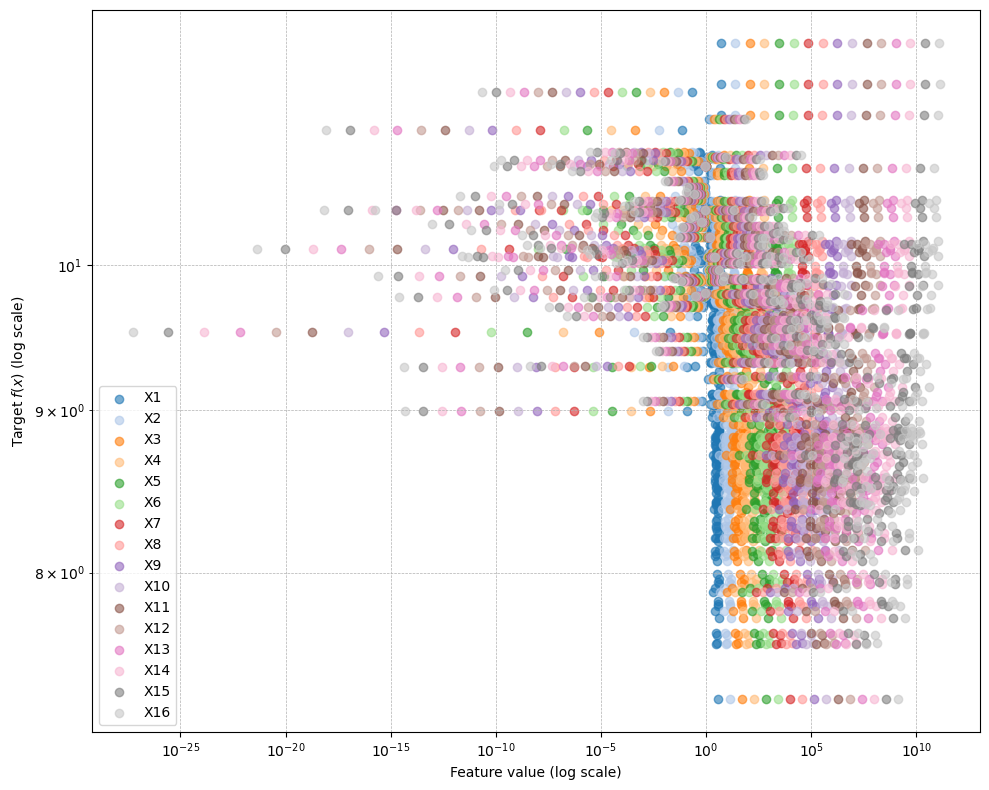

In [98]:
plot_all_features_with_model(X, y, None, True)

Тут уже действительно можно разглядеть какую-то упорядоченность значений параметров, которая в прочем не очевидна

In [99]:
from sklearn.model_selection import train_test_split

In [100]:
# Разбиение данных на обучающие и тестовые
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=10)
X_train[:2], y_train[:5]

(           X1        X2        X3        X4        X5        X6        X7  \
 235  0.612550  0.375217  0.229839  0.140788  0.086240  0.052826  0.032359   
 75   0.215487  0.046435  0.010006  0.002156  0.000465  0.000100  0.000022   
 
            X8        X9           X10           X11           X12  \
 235  0.019821  0.012142  7.437291e-03  4.555712e-03  2.790601e-03   
 75   0.000005  0.000001  2.158770e-07  4.651864e-08  1.002415e-08   
 
               X13           X14           X15           X16  
 235  1.709382e-03  1.047082e-03  6.413900e-04  3.928834e-04  
 75   2.160072e-09  4.654670e-10  1.003020e-10  2.161375e-11  ,
 235    10.475100
 75     11.339077
 211    10.152208
 290     9.768428
 226     9.773168
 Name: Y, dtype: float64)

In [101]:
model = CustomLinearRegression()

In [102]:
# Обучение
model.fit(X_train, y_train)
model.coef_

array([-1.23799966e+03,  1.17018899e+03, -4.92083143e+02,  1.30125770e+02,
       -2.37489537e+01,  2.23886670e+00,  9.16042976e-03,  6.40460771e-02,
        5.33159496e-02, -6.61914305e-02, -4.89842735e-03,  2.28265145e-02,
       -9.56345547e-03,  1.64179065e-03, -8.21742253e-05, -8.85278409e-06,
        9.06018981e-07])

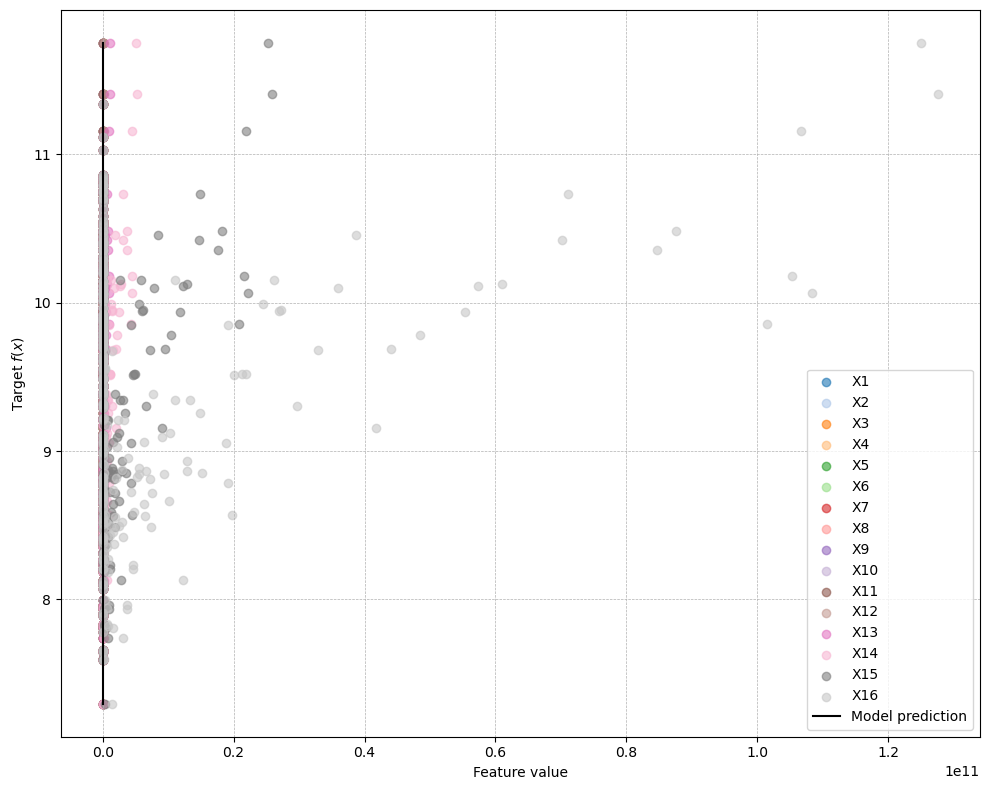

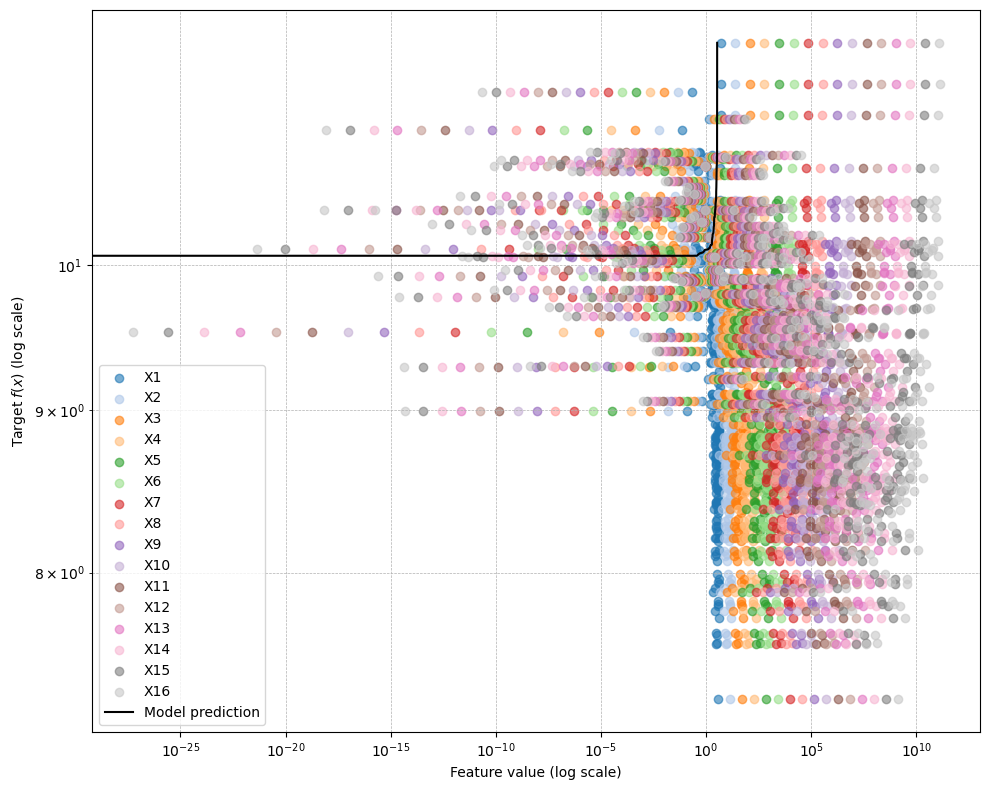

In [103]:
# Отображение наблюдений и линии регрессии
# plot_all_params_regression(X, y, model)
plot_all_features_with_model(X, y, model, False)
plot_all_features_with_model(X, y, model, True)

In [104]:
model.score(X_test, y_test)

-267461.43179214426

как видно, получена точность 70%

## 2 пункт

Реализовать класс, предназначенный для для стандартизации признаков в виде трансформации совместимый с `sklearn`. 

Передаваемые параметры: 
1. has_bias (содержит ли матрица вектор единиц), 
2. apply_mean (производить ли центровку)

In [105]:
class CustomStandardScaler(BaseEstimator, TransformerMixin):
    def __init__(self, has_bias=False, apply_mean=True):
        self.has_bias = has_bias
        self.apply_mean = apply_mean

    def fit(self, X, y=None):
        X = check_array(X)

        start_col = 1 if self.has_bias else 0
        self.mean_ = np.zeros(X.shape[1])
        self.std_ = np.ones(X.shape[1])

        if self.apply_mean:
            self.mean_[start_col:] = np.mean(X[:, start_col:], axis=0)
        self.std_[start_col:] = np.std(X[:, start_col:], axis=0, ddof=0)

        return self

    def transform(self, X):
        check_is_fitted(self, ["mean_", "std_"])
        X = check_array(X)

        X_scaled = (X - self.mean_) / self.std_
        if self.has_bias:
            X_scaled[:, 0] = X[:, 0]  # не трогаем bias-столбец

        return X_scaled

Создадим экземпляр нового класса:

In [106]:
scaler = CustomStandardScaler()

In [107]:
# Стандартизируем данные
scaler.fit(X)
X_scaled = scaler.transform(X)
# Отображение X
print("Исходные данные X:")
print(X[:5])

print("\nСтандартизированные данные X_scaled:")
print(X_scaled[:5])

Исходные данные X:
         X1         X2         X3          X4          X5           X6  \
0  3.856603  14.873388  57.360757  221.217682  853.148822  3290.256492   
1  0.103760   0.010766   0.001117    0.000116    0.000012     0.000001   
2  3.168241  10.037752  31.802020  100.756468  319.220791  1011.368453   
3  3.744019  14.017681  52.482471  196.495391  735.682558  2754.409777   
4  2.492535   6.212731  15.485450   38.598027   96.206935   239.799159   

             X7            X8            X9           X10           X11  \
0  1.268921e+04  4.893726e+04  1.887316e+05  7.278629e+05  2.807078e+06   
1  1.294799e-07  1.343480e-08  1.393992e-09  1.446402e-10  1.500783e-11   
2  3.204259e+03  1.015187e+04  3.216356e+04  1.019019e+05  3.228498e+05   
3  1.031256e+04  3.861044e+04  1.445582e+05  5.412288e+05  2.026371e+06   
4  5.977078e+02  1.489808e+03  3.713398e+03  9.255774e+03  2.307034e+04   

            X12           X13           X14           X15           X16  
0  1.082579

## 3 пункт

Реализуйте функции для расчета MSE и R^2 при отложенной выборке (run_holdout) и кросс-валидации (run_cross_val). Для кросс-валидации используйте только класс KFold. Выходными значениями должны быть MSE и R^2 для обучающей и тестовой частей.

Реализовать функции для расчета:
* MSE 
* R^2 

при: 
* отложенной выборке (run_holdout)
* кросс-валидации (run_cross_val) 

Для кросс-валидации используйте только класс KFold.
Выходными значениями должны быть MSE и R^2 для обучающей и тестовой частей.

In [108]:
# import numpy as np
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error, r2_score

def run_holdout(model, X, y, train_size, random_state) -> dict:
    """
    Функция для расчета MSE и R^2 на отложенной выборке (holdout).
    
    Parameters:
    model : объект модели с методами fit и predict
        Модель, которая обучается и делает предсказания.
    X : numpy array, shape (n_samples, n_features)
        Входные данные (матрица признаков).
    y : numpy array, shape (n_samples,)
        Целевые значения (метки).
    train_size : float
        Доля данных для обучения (от 0 до 1).
    random_state : int
        Сеятель для случайных операций (например, для разделения данных).
    
    Returns:
    dict : словарь с MSE и R^2 для обучающей и тестовой выборки
    """
    # Разделение на обучающую и тестовую выборки
    X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=train_size, random_state=random_state)

    # Обучение модели
    model.fit(X_train, y_train)

    # Предсказания для обучающей выборки
    y_train_pred = model.predict(X_train)
    # Предсказания для тестовой выборки
    y_test_pred = model.predict(X_test)

    # Вычисление MSE и R^2 для обучающей выборки
    mse_train = mean_squared_error(y_train, y_train_pred)
    r2_train = r2_score(y_train, y_train_pred)

    # Вычисление MSE и R^2 для тестовой выборки
    mse_test = mean_squared_error(y_test, y_test_pred)
    r2_test = r2_score(y_test, y_test_pred)

    # Возвращаем результаты в виде словаря
    scores = {
        "train_mse": mse_train,
        "train_r2": r2_train,
        "test_mse": mse_test,
        "test_r2": r2_test
    }

    return scores

In [111]:
def run_cross_val(model, X, y, n_splits, shuffle, random_state) -> dict:
    """
    Функция для расчета MSE и R^2 при кросс-валидации с использованием KFold.
    Работает с numpy-массивами и pandas.DataFrame.
    """
    kf = KFold(n_splits=n_splits, shuffle=shuffle, random_state=random_state)

    mse_train_list = []
    r2_train_list = []
    mse_test_list = []
    r2_test_list = []

    is_dataframe = isinstance(X, pd.DataFrame)

    for train_index, test_index in kf.split(X):
        if is_dataframe:
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        else:
            X_train, X_test = X[train_index], X[test_index]

        y_train, y_test = y[train_index], y[test_index]  # y можно оставить так, если это ndarray или Series

        model.fit(X_train, y_train)

        y_train_pred = model.predict(X_train)
        y_test_pred = model.predict(X_test)

        mse_train = mean_squared_error(y_train, y_train_pred)
        r2_train = r2_score(y_train, y_train_pred)

        mse_test = mean_squared_error(y_test, y_test_pred)
        r2_test = r2_score(y_test, y_test_pred)

        mse_train_list.append(mse_train)
        r2_train_list.append(r2_train)
        mse_test_list.append(mse_test)
        r2_test_list.append(r2_test)

    scores = {
        "mean_train_mse": np.mean(mse_train_list),
        "mean_train_r2": np.mean(r2_train_list),
        "mean_test_mse": np.mean(mse_test_list),
        "mean_test_r2": np.mean(r2_test_list)
    }

    return scores

Протестируем функции на практике:

In [112]:
# Примерные данные X и y
# X = np.random.rand(100, 2)
# y = np.random.rand(100)

# Отложенная выборка
holdout_scores = run_holdout(model, X, y, train_size=0.8, random_state=42)
print("Holdout Scores:\n", holdout_scores, "\n\n")

# Кросс-валидация
cross_val_scores = run_cross_val(model, X, y, n_splits=5, shuffle=True, random_state=42)
print("Cross-validation Scores:\n", cross_val_scores)


Holdout Scores:
 {'train_mse': 323.80467536580124, 'train_r2': -437.96283766265213, 'test_mse': 283.63232340296935, 'test_r2': -444.17031069601467} 


Cross-validation Scores:
 {'mean_train_mse': 8648.041149485038, 'mean_train_r2': -11917.659625772172, 'mean_test_mse': 8487.10004488193, 'mean_test_r2': -12366.794777076491}


## 4 пункт

Используя класс `Pipeline`, выполнить обучение линейной регрессии с предварительной стандартизацией с коэффициентом регуляризации равным 0 и 0.01. 
* Вывести значения параметров обученной модели. 
* Вывести значения `MSE` и `R^2`, полученные посредством функций `run_holdout` и `run_cross_val`. 
* Отобразить график **предсказание - действительное значение** для разных коэффициентов регуляризации для обучающего и текстового множества. 

Использовать следующие параметры:

- train_size=0.75,
- n_splits=4,
- shuffle=True,
- random_state=0

⚠️ Замечание. При формировании исходных данных использовался полином 16 степени одномерных данных.

In [113]:
from sklearn.pipeline import Pipeline


=== Alpha = 0 ===
Коэффициенты модели: [ 9.44892102e+00 -7.03547940e+01  2.20182480e+03 -3.36366924e+04
  2.78092237e+05 -1.36673313e+06  4.20056988e+06 -8.17021172e+06
  9.76537403e+06 -6.57353332e+06  2.26829454e+06 -9.62548645e+05
 -1.60704139e+05  3.53543413e+06 -5.07894556e+06  2.91979308e+06
 -6.23376338e+05]

Holdout:
{'train_mse': 0.40389816578817256, 'train_r2': 0.4327859634140475, 'test_mse': 0.5138313305105595, 'test_r2': 0.31471541331026487}
Cross-validation:
{'mean_train_mse': 0.31292503814057665, 'mean_train_r2': 0.5657209611303098, 'mean_test_mse': 0.35567023307491763, 'mean_test_r2': 0.5089972907420912}


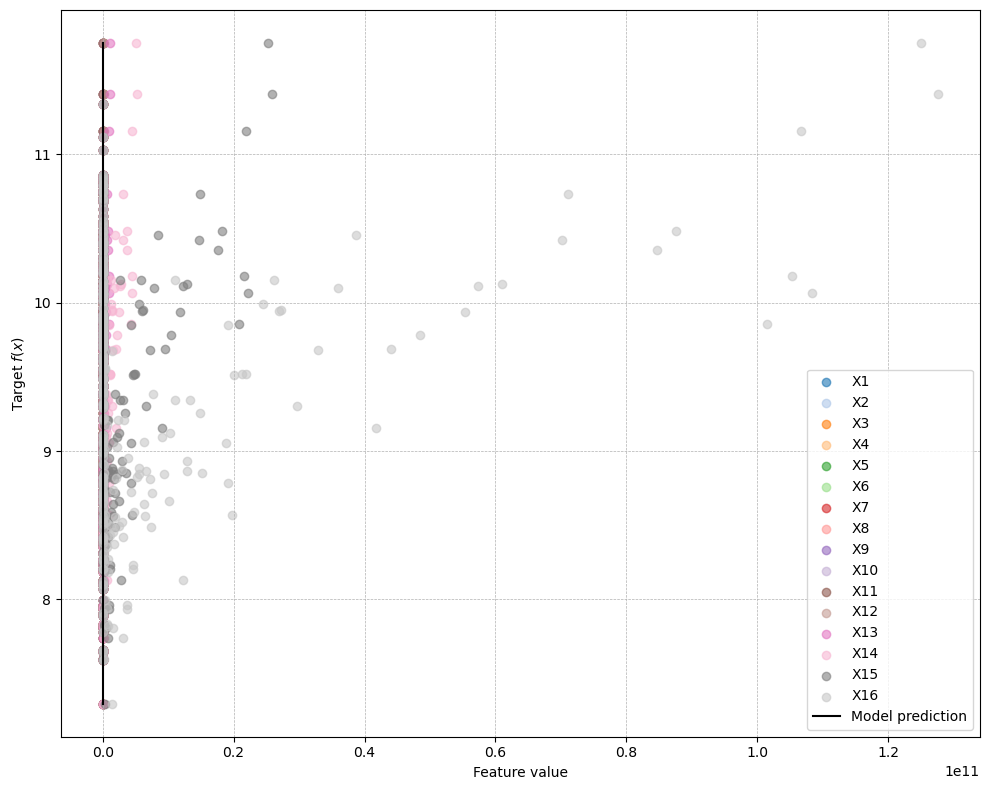

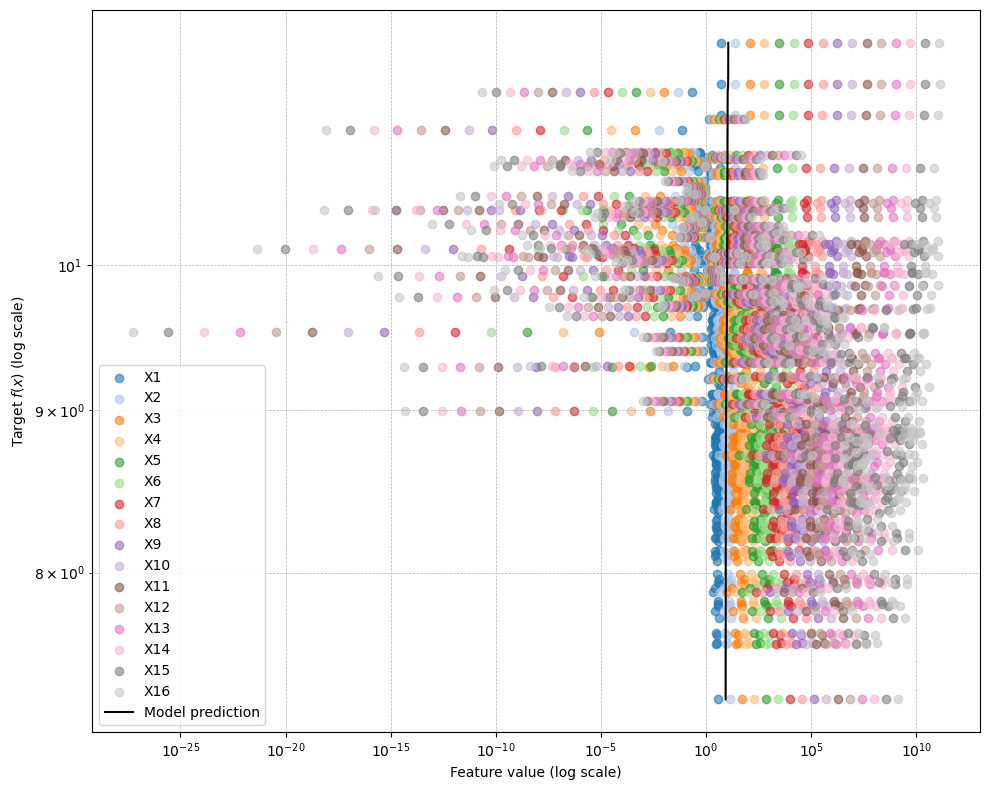


=== Alpha = 0.01 ===
Коэффициенты модели: [ 9.44892102  0.73224081 -1.9371805  -2.05758835  0.04016091  1.50257224
  1.75576136  1.24991695  0.50482578 -0.15904122 -0.60740753 -0.81643159
 -0.80818521 -0.61145388 -0.24338778  0.29569117  1.0206136 ]

Holdout:
{'train_mse': 0.2270305798213741, 'train_r2': 0.6811698033893329, 'test_mse': 0.22622187296302257, 'test_r2': 0.6982932851533139}
Cross-validation:
{'mean_train_mse': 0.2234877746432063, 'mean_train_r2': 0.6903145941352624, 'mean_test_mse': 0.23650799139328627, 'mean_test_r2': 0.6706063150780535}


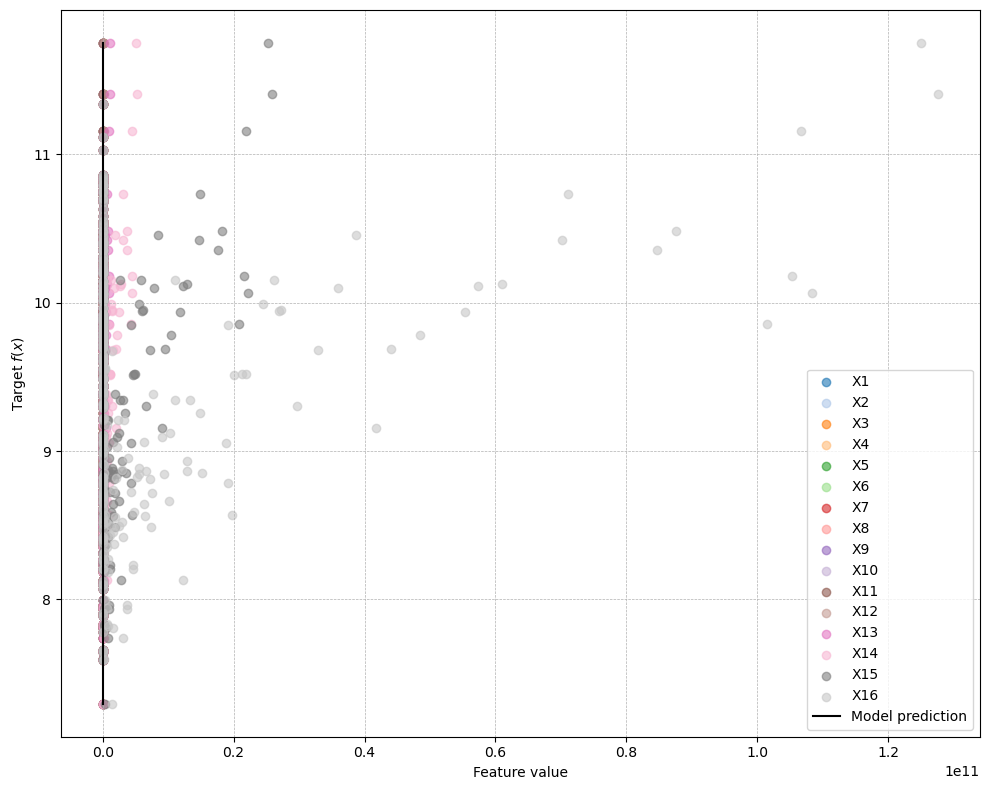

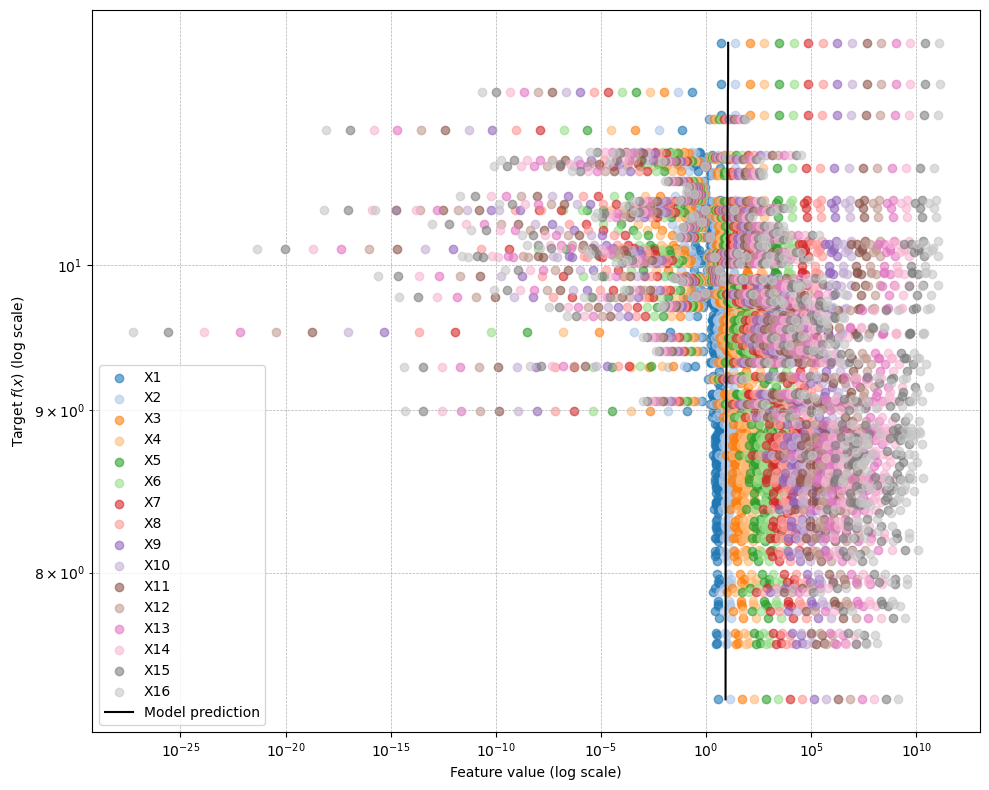

In [116]:
alphas = [0, 0.01]
train_size = 0.75
n_splits = 4
shuffle = True
random_state = 0

for alpha in alphas:
    print(f"\n=== Alpha = {alpha} ===")
    
    pipeline = Pipeline([
        ('scaler', CustomStandardScaler(has_bias=False, apply_mean=True)),
        ('customlinearregression', CustomLinearRegression(alpha=alpha))
    ])
    
    # --- Обучение
    pipeline.fit(X, y)
    
    # --- Коэффициенты
    coef = pipeline.named_steps['customlinearregression'].coef_
    print(f"Коэффициенты модели: {coef}\n")
    
    # --- Метрики: Holdout
    holdout_scores = run_holdout(pipeline, X, y, train_size, random_state)
    print("Holdout:")
    print(holdout_scores)
    
    # --- Метрики: Cross-validation
    cv_scores = run_cross_val(pipeline, X, y, n_splits, shuffle, random_state)
    print("Cross-validation:")
    print(cv_scores)
    
    # --- График
#     plot_regression(X, y, pipeline)
#     plot_all_features_with_model(X, y, pipeline, False)
#     plot_all_features_with_model(X, y, pipeline, True)

# Задача 2. Классификация и кросс-валидация

Дан набор входных данных (_вариант 2_)

Надо:
1. Найти степень полинома с **минимальной ошибкой** на проверочном подмножестве. 
2. Для лучшего случая рассчитать **ошибку на тестовом** подмножестве. 
В качестве метрики использовать долю правильных классификаций. 
4. Сделать заключение о **влиянии степени полинома на качество** предсказания.

Построить:

- **диаграмму разброса** исходных данных
- зависимость доли **правильных классификаций от степени полинома** для обучающего и проверочного подмножеств (две кривые на одном графике)
- **результат классификации** для наилучшего случая (степень полинома) для обучающего и тестового подмножеств с указанием границы принятия решения

Загрузим данные:

In [ ]:
data = pd.read_csv('./Cl_A5_V2.csv')
X = data.iloc[:, :-1].values  # все колонки кроме последней
y = data.iloc[:, -1].values   # последняя колонка — метка класса

Для исходных данных построим диаграмму разброса

In [ ]:
plt.figure(figsize=(5, 5))
plt.scatter(X[y==0][:,0], X[y==0][:,1], label='Class 0', alpha=0.5)
plt.scatter(X[y==1][:,0], X[y==1][:,1], label='Class 1', alpha=0.5)
plt.title("Scatter plot of input data")
plt.xlabel("X1")
plt.ylabel("X2")
plt.legend()
plt.grid(True)
plt.show()

Зададим параметры логистической регрессии

In [ ]:
logreg_params = {
    'penalty': 'l2',
    'fit_intercept': True,
    'max_iter': 100,
    'C': 1e5,
    'solver': 'liblinear',
    'random_state': 12345
}

Разобьем исходные данные:

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    train_size=0.7,
                                                    random_state=0)

Поиск наилучшей степени полинома:

In [ ]:
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LogisticRegression

In [ ]:
degrees = range(1, 11)
train_scores = []
val_scores = []

best_degree = None
best_score = 0
best_model = None

# --- Подбор степени полинома по отложенной выборке
for d in degrees:
    pipe = Pipeline([
        ('poly', PolynomialFeatures(degree=d)),
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(**logreg_params))
    ])
    pipe.fit(X_train, y_train)

    acc_train = pipe.score(X_train, y_train)
    acc_val = pipe.score(X_test, y_test)

    train_scores.append(acc_train)
    val_scores.append(acc_val)

    if acc_val > best_score:
        best_score = acc_val
        best_degree = d
        best_model = pipe

# --- Вывод лучшей степени и точности
print(f"Лучшая степень полинома по отложенной выборке: {best_degree}")
print(f"Accuracy на тестовом множестве: {best_score:.4f}\n")

График зависимости точности от степени:

In [ ]:
plt.figure(figsize=(6, 2))
plt.plot(degrees, train_scores, label='Train accuracy', marker='o')
plt.plot(degrees, val_scores, label='Test accuracy', marker='x')
plt.title("Accuracy vs Polynomial Degree")
plt.xlabel("Polynomial Degree")
plt.ylabel("Accuracy")
plt.legend()
plt.xticks(degrees) 
plt.grid(True)
plt.show()

отобразим границу классификации более наглядно:

In [ ]:
def plot_decision_boundary(model, X, y, title):
    h = .02
    x_min, x_max = X[:, 0].min() - .5, X[:, 0].max() + .5
    y_min, y_max = X[:, 1].min() - .5, X[:, 1].max() + .5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))

    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.figure(figsize=(5, 5))
    plt.contourf(xx, yy, Z, cmap=plt.cm.Paired, alpha=0.4)
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', cmap=plt.cm.Paired)
    plt.title(title)
    plt.xlabel("X1")
    plt.ylabel("X2")
    plt.grid(True)
    plt.show()

plot_decision_boundary(best_model, X_train, y_train,
                       f"Decision Boundary (Train, degree={best_degree})")
plot_decision_boundary(best_model, X_test, y_test,
                       f"Decision Boundary (Test, degree={best_degree})")

Проведем кроссвалидацию модели

In [ ]:
from sklearn.model_selection import cross_validate

In [ ]:
cv_scores = []
cv_train_scores = []

for d in degrees:
    pipe = Pipeline([
        ('poly', PolynomialFeatures(degree=d)),
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(**logreg_params))
    ])
    scores = cross_validate(pipe, X_train, y_train,
                            cv=4, scoring='accuracy',
                            return_train_score=True)
    cv_train_scores.append(np.mean(scores['train_score']))
    cv_scores.append(np.mean(scores['test_score']))

# --- Вывод результатов кросс-валидации
plt.figure(figsize=(6, 4))
plt.plot(degrees, cv_train_scores, label='CV train accuracy', marker='o')
plt.plot(degrees, cv_scores, label='CV validation accuracy', marker='x')
plt.title("Cross-Validation Accuracy vs Degree")
plt.xlabel("Polynomial Degree")
plt.ylabel("Accuracy")
plt.legend()
plt.xticks(degrees) 
plt.grid(True)
plt.show()

# --- Заключение
best_cv_deg = degrees[np.argmax(cv_scores)]
print(f"Лучшая степень по кросс-валидации: {best_cv_deg}")

# Задача 3. Классификация текстовых документов
### Вариант 2. Набор SMS сообщений (sms)

SMSSpamCollection

Подготовим данные, т.е. загрузим их и разобьем в отношении 80 на 20

In [ ]:
data = pd.read_csv("SMSSpamCollection", sep='\t', header=None, names=['label', 'text'])
data['label'] = data['label'].map({'ham': 0, 'spam': 1})

X = data['text']
y = data['label']

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8, stratify=y, random_state=123)

В этом задании нам надо найти лучшие гиперпараметры для разных классификаторов


Классификаторы:

In [ ]:
from sklearn.naive_bayes import BernoulliNB, MultinomialNB
from sklearn.neighbors import KNeighborsClassifier

In [ ]:
classifiers = {
    'knn': KNeighborsClassifier(),
    'logreg': LogisticRegression(penalty='l2', fit_intercept=True, max_iter=100, C=1e5,
                                 solver='liblinear', random_state=123),
    'bernoulli': BernoulliNB(),
    'multinomial': MultinomialNB()
}

Гиперпараметры:

In [ ]:
param_grids = {
    'knn': {'clf__n_neighbors': np.arange(1, 150, 20)},
    'logreg': {'clf__C': np.logspace(-2, 10, 8, base=10)},
    'bernoulli': {'clf__alpha': np.logspace(-4, 1, 8, base=10)},
    'multinomial': {'clf__alpha': np.logspace(-4, 1, 8, base=10)}
}

Разобьем задачу на логические шаги:

### 1
первым шагом надо найти лучшие гиперпараметры, при помощи стратифицированной кросс-валидации. 
> _Также сразу замерим время обучения._

In [ ]:
import time

In [ ]:
def run_grid_search(pipeline, param_grid, X, y, cv, scoring='balanced_accuracy'):
    grid = GridSearchCV(pipeline, param_grid=param_grid, cv=cv, scoring=scoring, return_train_score=True, n_jobs=-1)
    start_train = time.time()
    grid.fit(X, y)
    train_time = time.time() - start_train
    return grid, train_time

### 2
после необходимо отобразить модель

In [ ]:
def plot_grid_scores(grid, param_name, title):
    results = pd.DataFrame(grid.cv_results_)
    plt.figure()
    plt.plot(results['param_' + param_name], results['mean_train_score'], label='Train')
    plt.plot(results['param_' + param_name], results['mean_test_score'], label='Validation')
    plt.xscale('log' if results['param_' + param_name].dtype == np.float64 else 'linear')
    plt.xlabel(param_name)
    plt.ylabel('Balanced Accuracy')
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

### 3
Наконец надо собрать статистику по каждому классификатору, а именно:
* Balanced-Accuracy
* R
* P 
* F1

In [ ]:
from sklearn.metrics import balanced_accuracy_score, precision_score, recall_score, f1_score, classification_report

In [ ]:
def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)
    return {
        "Balanced Accuracy": balanced_accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-score": f1_score(y_test, y_pred)
    }

Теперь реализуем 2 цикла:
1. По n-garm
2. Вложенный, по классификаторам

In [ ]:
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.feature_extraction.text import CountVectorizer

In [ ]:
ngram_ranges = [(1, 1), (2, 2), (1, 2)]
results = []

for ngram in ngram_ranges:
    print(f"\n============== N-gram: {ngram} ==============")
    for name, clf in classifiers.items():
        print(f">>>>>>> Model: {name}")
        vectorizer = CountVectorizer(ngram_range=ngram, binary=(name == 'bernoulli'))
        pipeline = Pipeline([
            ('vect', vectorizer),
            ('clf', clf)
        ])
        param_grid = param_grids[name]
        cv = StratifiedKFold(n_splits=4, shuffle=True, random_state=123)
        grid, train_time = run_grid_search(pipeline, param_grid, X_train, y_train, cv)

        # Evaluate best model
        best_model = grid.best_estimator_
        start_pred = time.time()
        metrics = evaluate_model(best_model, X_test, y_test)
        pred_time = time.time() - start_pred

        # Log results
        results.append({
            "Model": name,
            "N-gram": ngram,
            "Best Param": grid.best_params_,
            "Train Time (s)": round(train_time, 3),
            "Predict Time (s)": round(pred_time, 3),
            **metrics
        })

        # Plot scores
        param_name = list(grid.best_params_.keys())[0]
        plot_grid_scores(grid, param_name, f"{name.upper()} (ngram={ngram})")

Выведем накопленные данные в виде таблицы:

In [ ]:
df_results = pd.DataFrame(results)
df_results.sort_values(by="Balanced Accuracy", ascending=False)